# Lending Default Risk Classifier\n\n**The actual business question:** if we lend to this customer, what's the chance they default (fail to repay)? This is different from *eligibility* — eligibility asks \"should we offer them a loan at all,\" default risk asks \"if we do, will they pay it back.\"\n\n**Target:** `Defaulted` (0/1) from `FactCustomerLending` — a new field added specifically for this notebook, since the warehouse previously had no repayment/default outcome at all, only an eligibility score.\n\n**Features:** demographics (age, gender, region), account (balance, type), the bank's own other model scores (churn, CLV, fraud), **and this time, legitimately, the lending-side fields themselves** — `LendingModelScore`, `Eligible`, `ApprovedLimit`. Unlike the earlier eligibility notebook, including these isn't circular: in real underwriting, a lender's own approval score and terms are genuine, independent signals about default risk, not the definition of it.\n\n**Deliberately excluded:** `DefaultRiskScore` — in the warehouse generator, `Defaulted` is a direct threshold of `DefaultRiskScore`, so including it would make this trivial and circular, exactly like `LendingModelScore` would have been for the eligibility notebook.\n\n**Class imbalance:** only ~12% of customers default in this synthetic data — realistic for a lending book, and handled below with stratified splitting and class-weighted models, plus a precision-recall view (not just ROC), since ROC-AUC can look deceptively good on imbalanced data.\n\n---\n**Important, read before presenting these results anywhere:** every field in this warehouse — churn score, CLV score, fraud score, lending score, and `Defaulted` itself — is a deterministic formula of `CustomerId`. None of it reflects real repayment behavior. The metrics below are real and honestly computed, but they measure how well a model reconstructs relationships between different synthetic formulas of the same integer, not genuine predictive skill on real-world credit risk. The value here is a correct, realistic default-risk pipeline end-to-end (including proper imbalance handling); swap in real historical repayment outcomes later and the exact same pipeline holds.

In [1]:
import os

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import pymssql
import seaborn as sns
from dotenv import load_dotenv
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split

load_dotenv()
sns.set_theme(style="whitegrid")
PURPLE = "#4a2382"
PURPLE_LIGHT = "#7c4bb8"
AMBER = "#b8722c"

## 1. Pull the data straight from the warehouse

In [2]:
conn = pymssql.connect(
    server=os.environ["MSSQL_SERVER"],
    port=int(os.environ.get("MSSQL_PORT", "1433")),
    database=os.environ["MSSQL_DATABASE"],
    user=os.environ["MSSQL_USER"],
    password=os.environ["MSSQL_PASSWORD"],
)

QUERY = """
SELECT
    c.CIF,
    c.Age,
    c.Gender,
    c.Region,
    c.CustomerType,
    c.Segment,
    c.CustomerStatus,
    a.Balance,
    a.AccountType,
    s.Score AS ChurnScore,
    s.RiskBand,
    clv.CLVScore,
    clv.CLVBand,
    f.FraudRiskScore,
    f.AlertLevel,
    l.LendingModelScore,
    l.Eligible,
    l.ApprovedLimit,
    l.Defaulted
FROM dbo.DimCustomer c
JOIN dbo.FactCustomerAccount a ON a.CustomerId = c.CustomerId
JOIN dbo.FactCustomerSegmentScore s ON s.CustomerId = c.CustomerId
JOIN dbo.FactCustomerCLV clv ON clv.CustomerId = c.CustomerId
JOIN dbo.FactFraudSignal f ON f.CustomerId = c.CustomerId
JOIN dbo.FactCustomerLending l ON l.CustomerId = c.CustomerId;
"""

df = pd.read_sql(QUERY, conn)
conn.close()

# pymssql returns BIT columns as Python bool - normalize to int so labels are
# always plain 0/1 throughout the notebook.
df["Eligible"] = df["Eligible"].astype(int)
df["Defaulted"] = df["Defaulted"].astype(int)

print(df.shape)
df.head()

/var/folders/xy/sts9z3rj3w3_957f1n6sltrm0000gn/T/ipykernel_35083/415263174.py:38: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(QUERY, conn)


(100000, 19)


,CIF,Age,Gender,Region,CustomerType,Segment,CustomerStatus,Balance,AccountType,ChurnScore,RiskBand,CLVScore,CLVBand,FraudRiskScore,AlertLevel,LendingModelScore,Eligible,ApprovedLimit,Defaulted
0,S000000002,31,Female,Port Harcourt,SME,Service SME,Active,50251.0,SME Current Account,0.122,Low,0.02,Low,0.012,Low,0.302,0,100500.0,0
1,R000000010,39,Female,Port Harcourt,Retail,Youth Retail,Dormant,51255.0,Savings Account,0.130,Low,0.10,Low,0.020,Low,0.310,0,102500.0,0
2,C000000027,56,Male,Kano,Corporate,SME Corporate,Active,53388.5,Current Account,0.147,Low,0.27,Low,0.037,Low,0.327,0,106750.0,0
3,R000000028,57,Female,Enugu,Retail,Mass Retail,Active,53514.0,Savings Account,0.148,Low,0.28,Low,0.038,Low,0.328,0,107000.0,0
4,S000000035,64,Male,Kano,SME,Service SME,Active,54392.5,SME Current Account,0.155,Low,0.35,Low,0.045,Low,0.335,0,108750.0,0


## 2. Exploratory data analysis — check the imbalance

Defaulted
0    0.881
1    0.119
Name: proportion, dtype: float64


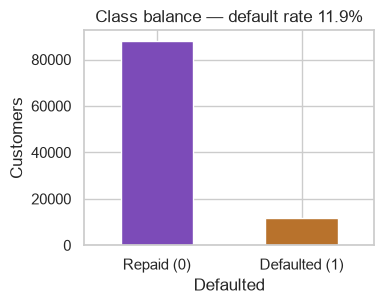

In [3]:
class_balance = df["Defaulted"].value_counts(normalize=True).sort_index()
print(class_balance)

fig, ax = plt.subplots(figsize=(4, 3.2))
df["Defaulted"].value_counts().sort_index().plot(kind="bar", ax=ax, color=[PURPLE_LIGHT, AMBER])
ax.set_xticklabels(["Repaid (0)", "Defaulted (1)"], rotation=0)
ax.set_ylabel("Customers")
ax.set_title(f"Class balance — default rate {class_balance[1]:.1%}")
plt.tight_layout()
plt.show()

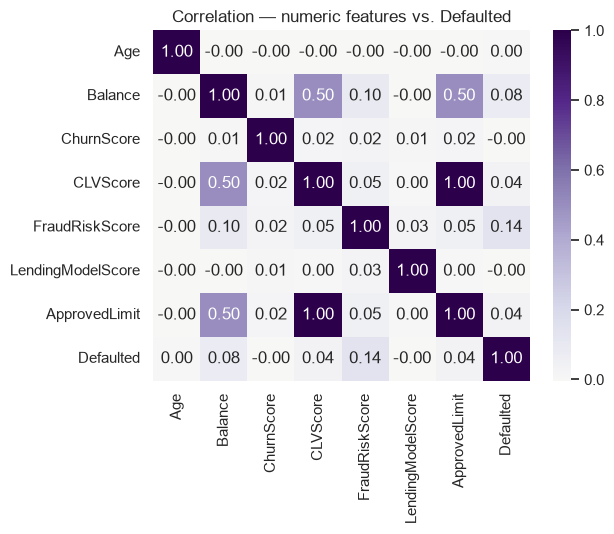

In [4]:
numeric_cols = [
    "Age", "Balance", "ChurnScore", "CLVScore", "FraudRiskScore",
    "LendingModelScore", "ApprovedLimit", "Defaulted",
]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="PuOr", center=0, ax=ax)
ax.set_title("Correlation — numeric features vs. Defaulted")
plt.tight_layout()
plt.show()

## 3. Preprocessing — encode categoricals, stratified train/test split\n\nStratifying matters more here than in a balanced problem — without it, a random split could easily leave the test set with a meaningfully different default rate than the training set.

In [5]:
FEATURE_COLS = [
    "Age", "Gender", "Region", "CustomerType", "Segment", "CustomerStatus",
    "Balance", "AccountType", "ChurnScore", "RiskBand", "CLVScore", "CLVBand",
    "FraudRiskScore", "AlertLevel", "LendingModelScore", "Eligible", "ApprovedLimit",
]

X = pd.get_dummies(df[FEATURE_COLS], drop_first=True)
y = df["Defaulted"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Train default rate:", y_train.mean().round(4), " Test default rate:", y_test.mean().round(4))

Train: (80000, 35)  Test: (20000, 35)
Train default rate: 0.119  Test default rate: 0.119


## 4. Model 1 — Logistic Regression (class-weighted baseline)

In [6]:
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)
y_pred_lr = logreg.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["Repaid", "Defaulted"]))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_lr), 4))

              precision    recall  f1-score   support

      Repaid       0.98      0.78      0.87     17620
   Defaulted       0.36      0.90      0.51      2380

    accuracy                           0.79     20000
   macro avg       0.67      0.84      0.69     20000
weighted avg       0.91      0.79      0.83     20000

Balanced accuracy: 0.8383


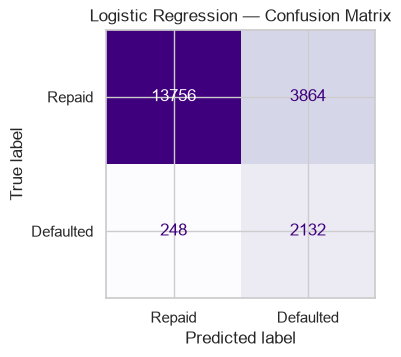

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, display_labels=["Repaid", "Defaulted"], cmap="Purples", ax=ax, colorbar=False
)
ax.set_title("Logistic Regression — Confusion Matrix")
plt.tight_layout()
plt.show()

## 5. Model 2 — Random Forest (class-weighted, non-linear)

In [8]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=42, class_weight="balanced"
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["Repaid", "Defaulted"]))
print("Balanced accuracy:", round(balanced_accuracy_score(y_test, y_pred_rf), 4))

              precision    recall  f1-score   support

      Repaid       1.00      0.90      0.95     17620
   Defaulted       0.57      1.00      0.72      2380

    accuracy                           0.91     20000
   macro avg       0.78      0.95      0.83     20000
weighted avg       0.95      0.91      0.92     20000

Balanced accuracy: 0.9485


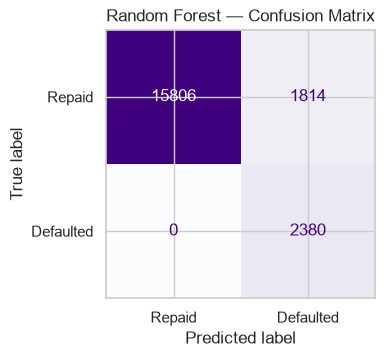

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=["Repaid", "Defaulted"], cmap="Purples", ax=ax, colorbar=False
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()

## 6. ROC and Precision-Recall — why both matter on imbalanced data\n\nROC-AUC can look strong on imbalanced data even when a model isn't very useful, because it's dominated by the large majority class. Precision-Recall focuses on the minority class (defaults) directly, which is what actually matters for a lending decision.

/Users/ZUHD_1/Documents/ml_hub/ml/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
/Users/ZUHD_1/Documents/ml_hub/ml/.venv/lib/python3.14/site-packages/sklearn/utils/_plotting.py:193: FutureWarning: `**kwargs` is deprecated and will be removed in 1.11. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


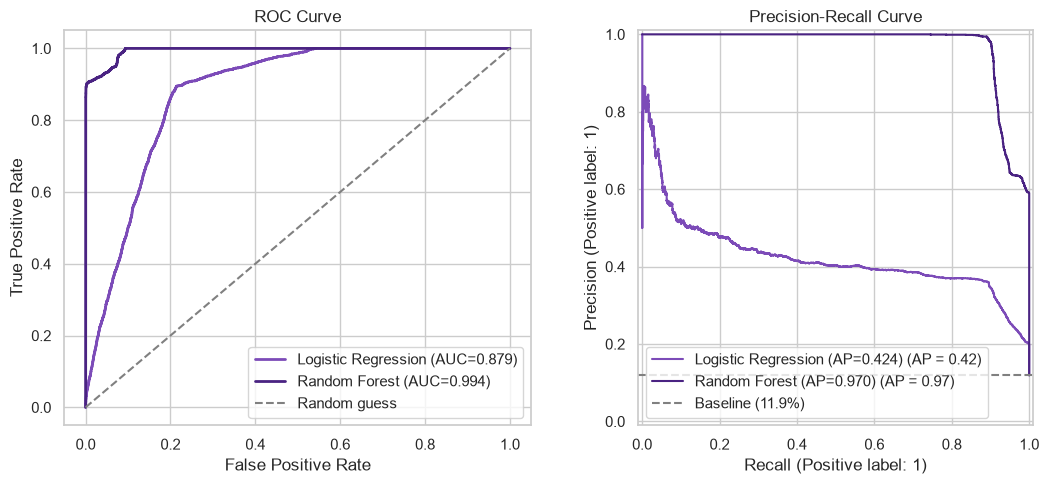

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

for name, model, color in [
    ("Logistic Regression", logreg, PURPLE_LIGHT),
    ("Random Forest", rf, PURPLE),
]:
    probs = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})", color=color, linewidth=2)

    ap = average_precision_score(y_test, probs)
    PrecisionRecallDisplay.from_predictions(
        y_test, probs, ax=axes[1], name=f"{name} (AP={ap:.3f})", color=color
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].axhline(y_test.mean(), linestyle="--", color="grey", label=f"Baseline ({y_test.mean():.1%})")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. What did the model actually key off? (feature importance)

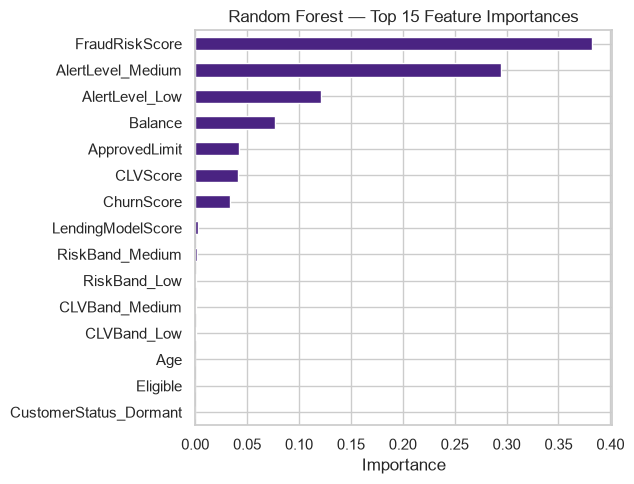

In [11]:
importances = (
    pd.Series(rf.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(6.5, 5))
importances.sort_values().plot(kind="barh", ax=ax, color=PURPLE)
ax.set_title("Random Forest — Top 15 Feature Importances")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

## 8. Save the trained models\n\nSaved but **not** wired into the running app — this notebook is a standalone analysis for now.

In [12]:
os.makedirs("models", exist_ok=True)
joblib.dump(logreg, "models/default_risk_logreg.joblib")
joblib.dump(rf, "models/default_risk_random_forest.joblib")
joblib.dump(list(X_train.columns), "models/default_risk_feature_columns.joblib")
print("Saved to ml/models/: default_risk_logreg.joblib, default_risk_random_forest.joblib, default_risk_feature_columns.joblib")

Saved to ml/models/: default_risk_logreg.joblib, default_risk_random_forest.joblib, default_risk_feature_columns.joblib


## Conclusion\n\nThis notebook answers the actual business question — *if we lend to this customer, what's the risk they default* — not eligibility. It correctly treats `LendingModelScore`, `Eligible`, and `ApprovedLimit` as legitimate input signals rather than circular ones, handles the realistic ~12% class imbalance with stratified splitting and class-weighted models, and reports precision-recall alongside ROC since that's the more honest lens on an imbalanced problem.\n\n**Same caveat as always, and it matters even more here:** `Defaulted` is a synthetic formula of `CustomerId`, not a real repayment outcome. The pipeline — extract → encode → split → train (class-weighted) → evaluate (ROC + PR) → explain → persist — is sound and reusable. The moment real historical repayment data replaces the synthetic `Defaulted` column, this exact notebook trains a genuinely meaningful default-risk model with no structural changes.\n\nWhen presenting this: lead with *\"I built a full default-risk pipeline, correctly handling class imbalance, using the bank's own lending signals as legitimate features\"* — not with the specific accuracy number, since that number's meaning is capped by the synthetic label.